# Ejemplo de Hashing Encoding para clasificación

En esta libreta veremos cómo **hashing encoding** puede ayudar cuando tenemos variables nominales con **alta cardinalidad**, es decir, columnas categóricas con muchísimos valores posibles.

El objetivo será construir un clasificador que prediga si una publicación pertenece al área de **Computación / IA** o **No Computación**, usando variables como:

- revista
- palabra clave
- editorial
- afiliación
- autor

La idea principal es comparar dos enfoques:

1. **One-hot encoding**, que crea una columna por cada categoría observada.
2. **Hashing encoding**, que transforma las categorías a un número fijo de columnas mediante una función hash.

El hashing encoding no siempre mejora la precisión por sí solo. Su principal ventaja es que permite usar variables categóricas enormes sin crear matrices inmanejables.


## 1. Importar librerías

Usaremos `pandas`, `numpy`, `scikit-learn` y `matplotlib`.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction import FeatureHasher
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Crear un conjunto de datos simulado

Simularemos publicaciones académicas. Algunas revistas, palabras clave, editoriales y afiliaciones estarán asociadas con Computación / IA; otras estarán asociadas con áreas no computacionales.

Además, agregaremos muchos autores diferentes para simular una columna nominal de alta cardinalidad. En bases reales, columnas como `autor`, `revista`, `afiliación`, `institución`, `congreso` o `keyword` pueden tener miles o decenas de miles de valores únicos.


In [3]:
df = pd.read_excel("Autores.xlsx")
df.head()


,revista,keyword,editorial,afiliacion,autor,computacion
0,Information Sciences,clustering,IEEE,Data Science Center,Autor_00503,1
1,IEEE Access,classification,Springer AI,Data Science Center,Autor_00320,1
2,Organic Letters,public policy,Elsevier Health,Economics Department,Autor_01006,0
3,Journal of Marine Biology,organic chemistry,Taylor Social Sciences,History Institute,Autor_00159,0
4,Pattern Recognition,classification,Springer AI,AI Laboratory,Autor_00169,1


## 3. Revisar cardinalidad de las variables nominales

La **cardinalidad** es el número de valores únicos en una columna. El hashing encoding es especialmente útil cuando esta cardinalidad es muy alta.


In [4]:
columnas_categoricas = ["revista", "keyword", "editorial", "afiliacion"]

cardinalidad = df[columnas_categoricas].nunique().sort_values(ascending=False)
cardinalidad


keyword       20
revista       18
editorial     10
afiliacion     8
dtype: int64

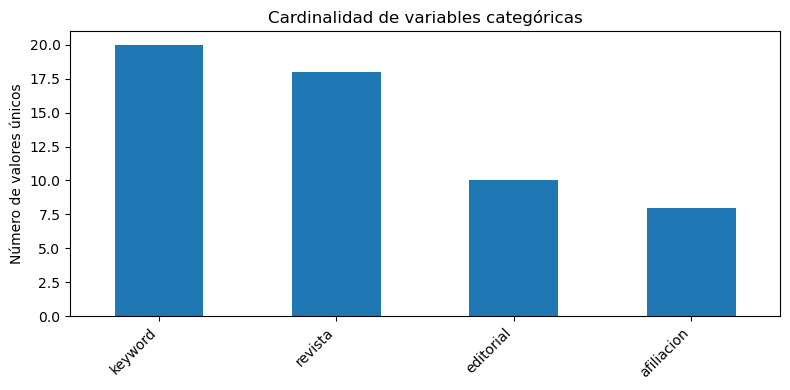

In [6]:
plt.figure(figsize=(8, 4))
cardinalidad.plot(kind="bar")
plt.title("Cardinalidad de variables categóricas")
plt.ylabel("Número de valores únicos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


En datos reales, el problema puede ser mucho mayor: decenas o cientos de miles de instituciones, palabras clave, productos, usuarios o identificadores.


## 4. División entrenamiento / prueba

Separaremos los datos en entrenamiento y prueba.


In [7]:
X = df[columnas_categoricas]
y = df["computacion"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train.shape, X_test.shape


((4500, 4), (1500, 4))

## 5. Clasificador con One-hot Encoding

Primero usaremos one-hot encoding. Este método conserva una columna independiente para cada categoría observada.

Ventaja: no hay colisiones entre categorías.

Desventaja: puede generar muchísimas columnas.


In [8]:
one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

modelo_one_hot = make_pipeline(
    one_hot,
    LogisticRegression(max_iter=1000)
)

modelo_one_hot.fit(X_train, y_train)

pred_one_hot = modelo_one_hot.predict(X_test)

acc_one_hot = accuracy_score(y_test, pred_one_hot)
f1_one_hot = f1_score(y_test, pred_one_hot)

# Número de columnas generadas por one-hot encoding
n_columnas_one_hot = modelo_one_hot.named_steps["onehotencoder"].transform(X_train).shape[1]

print(f"Columnas generadas por One-hot Encoding: {n_columnas_one_hot:,}")
print(f"Accuracy One-hot: {acc_one_hot:.3f}")
print(f"F1 One-hot: {f1_one_hot:.3f}")


Columnas generadas por One-hot Encoding: 56
Accuracy One-hot: 0.859
F1 One-hot: 0.860


## 6. Crear una función para Hashing Encoding

`FeatureHasher` de scikit-learn espera una lista de diccionarios o una lista de pares clave-valor. Para hacerlo claro, convertiremos cada fila en un diccionario donde cada categoría se representa como una cadena del tipo:

```text
columna=valor
```

Por ejemplo:

```text
revista=IEEE Access
keyword=machine learning
```

Esto evita que valores iguales en columnas diferentes se mezclen accidentalmente. Por ejemplo, `editorial=IEEE` y `keyword=IEEE` se tratarían como rasgos diferentes.


In [9]:
def filas_a_diccionarios(X_df):
    """Convierte un DataFrame categórico en una lista de diccionarios para FeatureHasher."""
    registros = []
    for _, fila in X_df.iterrows():
        d = {}
        for columna, valor in fila.items():
            # El valor 1 indica presencia de esa categoría.
            d[f"{columna}={valor}"] = 1
        registros.append(d)
    return registros

# Ejemplo de cómo queda una fila
filas_a_diccionarios(X_train.head(1))[0]


{'revista=IEEE Access': 1,
 'keyword=artificial intelligence': 1,
 'editorial=Springer AI': 1,
 'afiliacion=Computer Science Department': 1}

## 7. Clasificador con Hashing Encoding

Ahora usaremos hashing encoding. La diferencia clave es que fijamos de antemano el número de columnas, por ejemplo 30, 40, 50 o 56.

Aunque haya 56 features, el vector final siempre tendrá el número de columnas que indiquemos.

FeatureHasher aplicará una función hash a cada clave->valor y decidirá en qué columna colocarlos.
"revista=IEEE Access"          → columna 2
"keyword=machine learning"     → columna 6
"editorial=Elsevier"           → columna 4


In [14]:
def entrenar_con_hashing(n_features):
    hasher = FeatureHasher(
        n_features=n_features,
        input_type="dict",
        alternate_sign=False
    )

    X_train_hash = hasher.transform(filas_a_diccionarios(X_train))
    X_test_hash = hasher.transform(filas_a_diccionarios(X_test))

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_hash, y_train)

    pred = clf.predict(X_test_hash)

    return {
        "n_features_hashing": n_features,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "modelo": clf,
        "hasher": hasher,
        "X_train_hash": X_train_hash,
        "X_test_hash": X_test_hash,
        "pred": pred
    }

resultado_hash_50 = entrenar_con_hashing(50)

print(resultado_hash_50['X_train_hash'])
print(f"Columnas generadas por Hashing Encoding: {resultado_hash_50['n_features_hashing']:,}")
print(f"Accuracy Hashing: {resultado_hash_50['accuracy']:.3f}")
print(f"F1 Hashing: {resultado_hash_50['f1']:.3f}")


  (0, 11)	1.0
  (0, 22)	1.0
  (0, 24)	1.0
  (0, 38)	1.0
  (1, 6)	1.0
  (1, 27)	1.0
  (1, 32)	1.0
  (1, 47)	1.0
  (2, 7)	1.0
  (2, 11)	1.0
  (2, 22)	1.0
  (2, 48)	1.0
  (3, 5)	1.0
  (3, 17)	1.0
  (3, 35)	1.0
  (3, 37)	1.0
  (4, 2)	1.0
  (4, 29)	1.0
  (4, 30)	1.0
  (4, 49)	1.0
  (5, 2)	1.0
  (5, 7)	1.0
  (5, 19)	1.0
  (5, 49)	1.0
  (6, 8)	1.0
  :	:
  (4493, 48)	1.0
  (4494, 10)	1.0
  (4494, 14)	1.0
  (4494, 32)	1.0
  (4494, 40)	1.0
  (4495, 13)	1.0
  (4495, 22)	1.0
  (4495, 29)	1.0
  (4495, 30)	1.0
  (4496, 3)	1.0
  (4496, 25)	1.0
  (4496, 40)	1.0
  (4496, 48)	1.0
  (4497, 11)	1.0
  (4497, 27)	1.0
  (4497, 37)	1.0
  (4497, 41)	1.0
  (4498, 8)	1.0
  (4498, 11)	1.0
  (4498, 17)	1.0
  (4498, 49)	1.0
  (4499, 5)	1.0
  (4499, 13)	1.0
  (4499, 27)	1.0
  (4499, 30)	1.0
Columnas generadas por Hashing Encoding: 50
Accuracy Hashing: 0.858
F1 Hashing: 0.859


## 8. Comparar One-hot Encoding vs Hashing Encoding

El punto importante no es sólo la métrica, sino la relación entre:

- calidad predictiva
- número de columnas
- eficiencia computacional

Con hashing encoding podemos obtener un desempeño competitivo usando muchas menos columnas.


In [21]:
comparacion = pd.DataFrame([
    {
        "metodo": "One-hot encoding",
        "columnas": n_columnas_one_hot,
        "accuracy": acc_one_hot,
        "f1": f1_one_hot
    },
    {
        "metodo": "Hashing encoding 50",
        "columnas": resultado_hash_50["n_features_hashing"],
        "accuracy": resultado_hash_50["accuracy"],
        "f1": resultado_hash_50["f1"]
    }
])

comparacion


,metodo,columnas,accuracy,f1
0,One-hot encoding,56,0.858667,0.859788
1,Hashing encoding 50,50,0.858000,0.859034


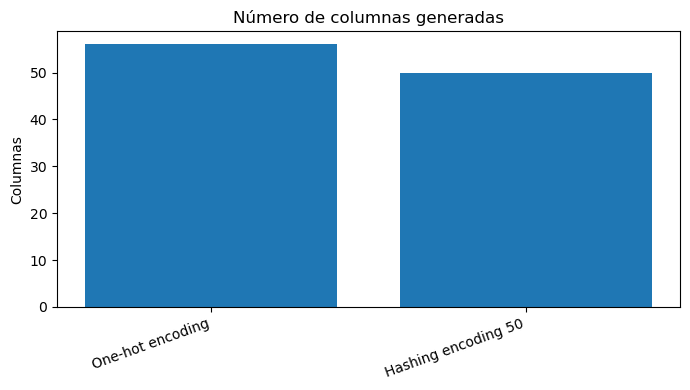

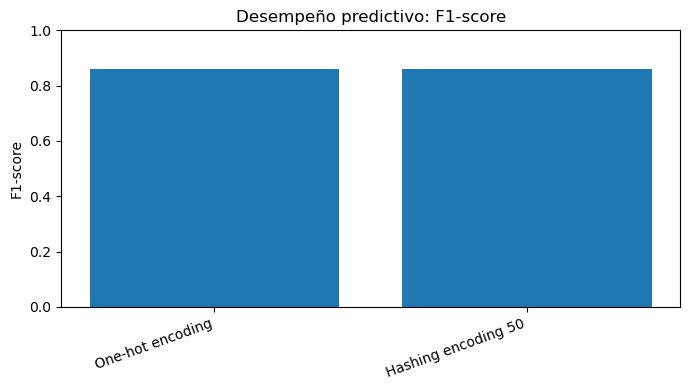

In [22]:
plt.figure(figsize=(7, 4))
plt.bar(comparacion["metodo"], comparacion["columnas"])
plt.title("Número de columnas generadas")
plt.ylabel("Columnas")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(comparacion["metodo"], comparacion["f1"])
plt.title("Desempeño predictivo: F1-score")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 9. ¿Qué pasa si cambiamos el número de columnas del hashing?

Si usamos muy pocas columnas, aumentan las colisiones: varias categorías distintas caen en la misma posición del vector.

Si usamos más columnas, hay menos colisiones, pero también aumenta el tamaño de la matriz.

Probemos varios tamaños.


In [23]:
tamanos_hash = [8, 16, 32, 40]
resultados_hash = []

for n in tamanos_hash:
    res = entrenar_con_hashing(n)
    resultados_hash.append({
        "columnas_hashing": n,
        "accuracy": res["accuracy"],
        "f1": res["f1"]
    })

resultados_hash = pd.DataFrame(resultados_hash)
resultados_hash


,columnas_hashing,accuracy,f1
0,8,0.799333,0.795655
1,16,0.835333,0.831169
2,32,0.840667,0.837525
3,40,0.849333,0.851316


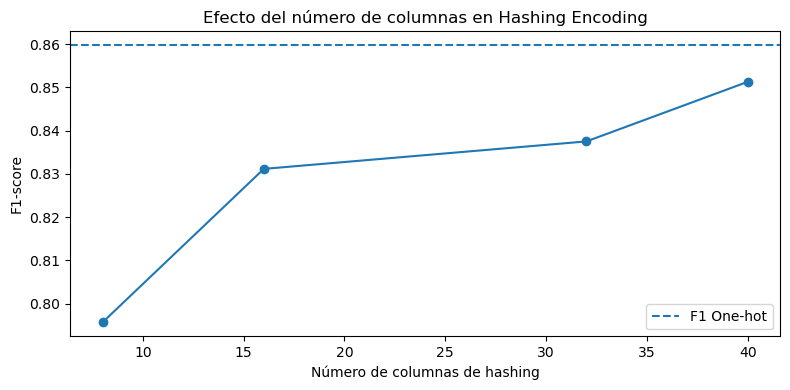

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(resultados_hash["columnas_hashing"], resultados_hash["f1"], marker="o")
plt.axhline(f1_one_hot, linestyle="--", label="F1 One-hot")
#plt.xscale("log", base=2)
plt.title("Efecto del número de columnas en Hashing Encoding")
plt.xlabel("Número de columnas de hashing")
plt.ylabel("F1-score")
plt.legend()
plt.tight_layout()
plt.show()


La gráfica suele mostrar un patrón intuitivo:

- con muy pocas columnas, el rendimiento puede ser bajo por demasiadas colisiones;
- al aumentar las columnas, el rendimiento mejora;
- después de cierto punto, agregar más columnas ya no aporta mucho.

Esto ilustra que hashing encoding permite controlar el compromiso entre **tamaño de la representación** y **desempeño del modelo**.


## 10. Matriz de confusión del modelo con Hashing Encoding

Veamos los errores del modelo con hashing encoding usando 128 columnas.


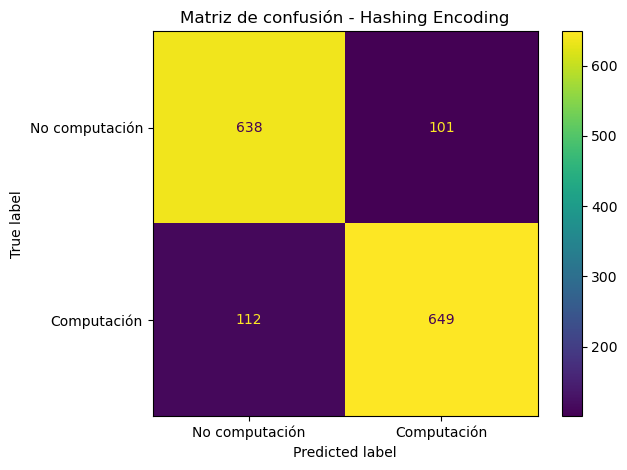

                precision    recall  f1-score   support

No computación       0.85      0.86      0.86       739
   Computación       0.87      0.85      0.86       761

      accuracy                           0.86      1500
     macro avg       0.86      0.86      0.86      1500
  weighted avg       0.86      0.86      0.86      1500



In [25]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    resultado_hash_50["pred"],
    display_labels=["No computación", "Computación"]
)
plt.title("Matriz de confusión - Hashing Encoding")
plt.tight_layout()
plt.show()

print(classification_report(
    y_test,
    resultado_hash_50["pred"],
    target_names=["No computación", "Computación"]
))


## 11. ¿Por qué Hashing Encoding ayuda aquí?

En este ejemplo, el modelo logra clasificar bien porque ciertas categorías son informativas.

Por ejemplo, publicaciones con valores como:

- `keyword=machine learning`
- `keyword=computer vision`
- `revista=Neural Networks`
- `editorial=IEEE`
- `afiliacion=AI Laboratory`

aparecen con mayor frecuencia en la clase **Computación**.

El hashing encoding transforma esas señales en posiciones de un vector de tamaño fijo. El clasificador aprende que ciertas posiciones del vector aumentan o disminuyen la probabilidad de pertenecer a Computación.

La gran ventaja es que esto ocurre sin tener que crear una columna explícita para cada valor posible.


## 12. Ventajas y limitaciones

### Ventajas

- Funciona bien con variables categóricas de alta cardinalidad.
- Produce una representación de tamaño fijo.
- No necesita guardar un diccionario completo de categorías.
- Puede manejar categorías nuevas en prueba o producción.
- Es eficiente para problemas grandes.

### Limitaciones

- Puede haber colisiones: dos categorías diferentes pueden caer en la misma columna.
- Es menos interpretable que one-hot encoding.
- El número de columnas debe elegirse con cuidado.
- Si hay demasiadas colisiones, el desempeño puede bajar.


## 13. Conclusión

Hashing encoding es útil cuando tenemos muchas categorías nominales y necesitamos alimentar un modelo de clasificación con una representación numérica compacta.

En términos prácticos:

```text
One-hot encoding:
100,000 categorías → hasta 100,000 columnas
```

```text
Hashing encoding:
100,000 categorías → 512, 1024 o 4096 columnas, según lo que decidamos
```

Por eso es especialmente útil en problemas como:

- clasificación de textos;
- clasificación de publicaciones académicas;
- detección de spam;
- recomendación de productos;
- clasificación de usuarios o eventos;
- integración de datos con muchas entidades nominales.

La idea central es que el hashing encoding sacrifica algo de interpretabilidad y acepta posibles colisiones a cambio de una representación compacta, rápida y escalable.
